In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

#import the necessary packages
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from pathlib import Path
from collections import Counter

In [3]:
from tensorflow.keras.applications import MobileNet, MobileNetV2, MobileNetV3Small, MobileNetV3Large, VGG16
from tensorflow.keras.applications import EfficientNetV2B0, ConvNeXtSmall, DenseNet121,ResNet50,InceptionV3,EfficientNetB0
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D,Flatten,Dropout
from tensorflow.keras.models import Model
from tensorflow import keras
from tensorflow.keras.applications.mobilenet import preprocess_input as mob_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess_input
from tensorflow.keras.applications.convnext import preprocess_input as conv_preprocess_input
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg_preprocess_input

2025-06-03 05:30:36.648543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748928636.875465      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748928636.946213      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [4]:
import tensorflow as tf

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPUs are available:")
    for gpu in gpus:
        print(gpu)
else:
    print("No GPUs detected.")

GPUs are available:
PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
#read label information
df = pd.read_csv('/kaggle/input/deepweeds/labels.csv')
df.head()

,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [6]:
df[['Species','Label']].groupby(by='Species').count().T

Species,Chinee apple,Lantana,Negative,Parkinsonia,Parthenium,Prickly acacia,Rubber vine,Siam weed,Snake weed
Label,1125,1064,9106,1031,1022,1062,1009,1074,1016


In [7]:
label2id = df[['Species','Label']].groupby(by='Species').min().to_dict()['Label']
id2label = {label2id[i]:i for i in label2id}
id2label

{0: 'Chinee apple',
 1: 'Lantana',
 8: 'Negative',
 2: 'Parkinsonia',
 3: 'Parthenium',
 4: 'Prickly acacia',
 5: 'Rubber vine',
 6: 'Siam weed',
 7: 'Snake weed'}

In [8]:
num_classes = len(df['Label'].unique())
num_classes

9

In [9]:
df1=df[['Filename','Label']]
df1['Label']=df['Label'].astype(int)
df1['Species'] = df1['Label'].map(id2label)
df1.head()

/tmp/ipykernel_19/2892309576.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['Label']=df['Label'].astype(int)


,Filename,Label,Species
0,20160928-140314-0.jpg,0,Chinee apple
1,20160928-140337-0.jpg,0,Chinee apple
2,20160928-140731-0.jpg,0,Chinee apple
3,20160928-140747-0.jpg,0,Chinee apple
4,20160928-141107-0.jpg,0,Chinee apple


In [10]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(df1, test_size=0.3, shuffle=True, random_state=23, stratify=df['Label'])
train = train.reset_index(drop=True)
test = test.reset_index(drop=True)
len(train), len(test)

(12256, 5253)

In [11]:
df1['Species'].value_counts()

Species
Negative          9106
Chinee apple      1125
Siam weed         1074
Lantana           1064
Prickly acacia    1062
Parkinsonia       1031
Parthenium        1022
Snake weed        1016
Rubber vine       1009
Name: count, dtype: int64

In [12]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    #rescale=1./255,
    rotation_range=30,
    brightness_range=[0.6, 1.5],
    channel_shift_range=20.0,
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.25,
    height_shift_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Set validation split
)

In [13]:
image_size = (256, 256)  # Change based on your model's requirements
batch_size = 32

In [14]:
img_dir='/kaggle/input/deepweeds/images'

In [15]:
# Train Data Generator
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use subset for training
)

Found 9805 validated image filenames belonging to 9 classes.


In [16]:
print("Class indices:", train_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [17]:
import numpy as np
from collections import Counter

# Assuming train_generator is your training data generator
class_indices = train_generator.classes  # numpy array of class indices

# Count samples per class
class_counts = np.array([count for _, count in sorted(Counter(class_indices).items())])

print("Class counts:", class_counts)


Class counts: [ 634  598 5073  569  593  604  566  598  570]


In [18]:
inv_freq = 1.0 / class_counts
alpha = inv_freq / np.sum(inv_freq)
alpha = alpha.tolist()
alpha

[0.11479945057310705,
 0.12171045428653825,
 0.0143471026342105,
 0.12791362330992948,
 0.12273668071391208,
 0.12050141003865873,
 0.12859161071263228,
 0.12171045428653825,
 0.12768921344447345]

In [19]:
# Validation Data Generator
validation_generator = train_datagen.flow_from_dataframe(
    dataframe=train,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use subset for validation
)

Found 2451 validated image filenames belonging to 9 classes.


In [20]:
print("Class indices:", validation_generator.class_indices)

Class indices: {'Chinee apple': 0, 'Lantana': 1, 'Negative': 2, 'Parkinsonia': 3, 'Parthenium': 4, 'Prickly acacia': 5, 'Rubber vine': 6, 'Siam weed': 7, 'Snake weed': 8}


In [21]:
# Create ImageDataGenerator for test (no augmentation)
test_datagen = ImageDataGenerator(
    #rescale=1./255
    )

In [22]:
# Test Data Generator
test_generator = test_datagen.flow_from_dataframe(
    dataframe=test,
    directory=img_dir,
    x_col='Filename',
    y_col='Species',  # Assuming test data might still have labels, if not, use None
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',  # Use 'None' if no labels are available
    shuffle=False  # Important for test data to maintain order
)

Found 5253 validated image filenames belonging to 9 classes.


In [23]:
import tensorflow as tf
from tensorflow.keras import layers, models

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K
import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.layers import Input, Conv2D, GlobalAveragePooling2D, Dense, Multiply, Concatenate, BatchNormalization, Activation,Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, Concatenate, Multiply
    
def cbam_spatial_attention(input_feature):
    # Use Lambda layers to wrap tf functions
    avg_pool = Lambda(lambda x: tf.reduce_mean(x, axis=-1, keepdims=True))(input_feature)
    max_pool = Lambda(lambda x: tf.reduce_max(x, axis=-1, keepdims=True))(input_feature)
    # Concatenate along channel axis
    concat = Concatenate(axis=-1)([avg_pool, max_pool])  # (H, W, 2)

    # Apply 7x7 convolution → 1-channel spatial attention map
    attention = Conv2D(filters=1, kernel_size=7, padding='same', activation='sigmoid')(concat)  # (H, W, 1)

    # Multiply attention map with input feature map
    output = Multiply()([input_feature, attention])

    return output

In [24]:
from tensorflow.keras.layers import (
    Dense, GlobalAveragePooling2D, GlobalMaxPooling2D,
    Reshape, Add, Activation, Multiply, Permute
)
from tensorflow.keras import backend as K

def channel_attention(input_feature, ratio=8):
    channel_axis = 1 if K.image_data_format() == "channels_first" else -1
    channel = K.int_shape(input_feature)[channel_axis]

    shared_layer_one = Dense(channel // ratio,
                             activation='relu',
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')
    shared_layer_two = Dense(channel,
                             kernel_initializer='he_normal',
                             use_bias=True,
                             bias_initializer='zeros')

    avg_pool = GlobalAveragePooling2D()(input_feature)
    avg_pool = Reshape((1, 1, channel))(avg_pool)
    avg_pool = shared_layer_one(avg_pool)
    avg_pool = shared_layer_two(avg_pool)

    max_pool = GlobalMaxPooling2D()(input_feature)
    max_pool = Reshape((1, 1, channel))(max_pool)
    max_pool = shared_layer_one(max_pool)
    max_pool = shared_layer_two(max_pool)

    cbam_feature = Add()([avg_pool, max_pool])
    cbam_feature = Activation('sigmoid')(cbam_feature)

    if K.image_data_format() == "channels_first":
        cbam_feature = Permute((3, 1, 2))(cbam_feature)

    return Multiply()([input_feature, cbam_feature])


In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
from tensorflow.keras.applications import EfficientNetV2B0

# from tensorflow.keras import mixed_precision
# mixed_precision.set_global_policy('mixed_float16')

# --- ConvBlock Definition ---
class ConvBlock(layers.Layer):
    def __init__(self, filters=256, kernel_size=3, dilation_rate=1, **kwargs):
        super(ConvBlock, self).__init__(**kwargs)
        self.filters = filters
        self.kernel_size = kernel_size
        self.dilation_rate = dilation_rate
        self.net = tf.keras.Sequential([
            layers.Conv2D(filters, kernel_size=kernel_size, padding='same', dilation_rate=dilation_rate, use_bias=False,
                          kernel_initializer='he_normal'),
            layers.BatchNormalization(),
            layers.ReLU()
        ])

    def call(self, X):
        return self.net(X)

    def get_config(self):
        base_config = super().get_config()
        return {
            **base_config,
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "dilation_rate": self.dilation_rate,
        }

# --- Atrous Spatial Pyramid Pooling (ASPP) ---

#@tf.function
def AtrousSpatialPyramidPooling(X):
    B, H, W, C = X.shape

    # Image Pooling
    # image_pool = layers.AveragePooling2D(pool_size=(H, W))(X)
    # image_pool = ConvBlock(kernel_size=1)(image_pool)
    # image_pool = layers.UpSampling2D(size=(H // image_pool.shape[1], W // image_pool.shape[2]))(image_pool)

    image_pool = layers.GlobalAveragePooling2D()(X)
    image_pool = layers.Reshape((1, 1, C))(image_pool)
    image_pool = ConvBlock(kernel_size=1)(image_pool)
    image_pool = layers.UpSampling2D(size=(H, W), interpolation='bilinear')(image_pool)
    # Atrous Operations using dilation
    conv_1 = ConvBlock(kernel_size=1, dilation_rate=1)(X)
    conv_6 = ConvBlock(kernel_size=3, dilation_rate=6)(X)
    conv_12 = ConvBlock(kernel_size=3, dilation_rate=12)(X)
    conv_18 = ConvBlock(kernel_size=3, dilation_rate=18)(X)

    # Combine All
    combined = layers.Concatenate()([image_pool,conv_1, conv_6, conv_12, conv_18])
    processed = ConvBlock(kernel_size=1)(combined)

    return processed

In [26]:
base_model = keras.applications.EfficientNetV2B0(
    weights='imagenet',  # Load weights pre-trained on ImageNet.
    input_shape=image_size + (3,),
    include_top=False) 
base_model.trainable = True

I0000 00:00:1748928726.810605      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [27]:
import tensorflow as tf
import math

class ECALayer(tf.keras.layers.Layer):
    def __init__(self, gamma=2, b=1, **kwargs):
        super(ECALayer, self).__init__(**kwargs)
        self.gamma = gamma
        self.b = b

    def build(self, input_shape):
        channels = input_shape[-1]
        t = int(abs((math.log2(channels) / self.gamma) + self.b))
        self.k_size = t if t % 2 == 1 else t + 1
        self.conv1d = tf.keras.layers.Conv1D(
            filters=1,
            kernel_size=self.k_size,
            padding='same',
            use_bias=False
        )

    def call(self, x):
        # x: [B, H, W, C]
        squeeze = tf.reduce_mean(x, axis=[1, 2], keepdims=True)  # [B, 1, 1, C]
        squeeze = tf.transpose(squeeze, [0, 3, 1, 2])            # [B, C, 1, 1]
        squeeze = tf.squeeze(squeeze, axis=[2, 3])               # [B, C]
        squeeze = tf.expand_dims(squeeze, axis=-1)              # [B, C, 1]
        attn = self.conv1d(squeeze)                              # [B, C, 1]
        attn = tf.nn.sigmoid(attn)                               # [B, C, 1]
        attn = tf.reshape(attn, [-1, 1, 1, x.shape[-1]])         # [B, 1, 1, C]
        return x * attn


In [28]:
#base_model.summary()

In [29]:
def cbam_block(cbam_feature, ratio=8):
    """Contains the implementation of Convolutional Block Attention Module(CBAM) block.
    As described in https://arxiv.org/abs/1807.06521.
    """

    cbam_feature = channel_attention(cbam_feature, ratio)
    cbam_feature = cbam_spatial_attention(cbam_feature)

    return cbam_feature

In [30]:
# def gated_fusion(cbam_feature, original_feature):
#     # Concatenate both features
#     concat = Concatenate()([cbam_feature, original_feature])
    
#     # Learn spatial gate (1-channel mask)
#     gate = Conv2D(1, kernel_size=1, activation='sigmoid', padding='same')(concat)
    
#     # Repeat gate over channels
#     gate = Lambda(lambda x: tf.repeat(x, cbam_feature.shape[-1], axis=-1))(gate)

#     # Weighted fusion
#     return Add()([
#         Multiply()([cbam_feature, gate]),
#         Multiply()([original_feature, 1 - gate])
#     ])

In [31]:
def build_model(base_model, num_classes):
    inputs = Input(shape=image_size + (3,))
    x = base_model(inputs, training=False)
    original_features = x

    # CBAM attention modules
    #cbam_channel = channel_attention(x)
    eca=ECALayer()(x)
    x = cbam_spatial_attention(eca)
    #result1 = Add()([eca, cbam_spatial])
    #result2 = cbam_block(x, ratio=8)
    #cbam_feature = Add()([result1, result2])

    # Gated feature fusion
    #x = gated_fusion(cbam_feature, original_features)

    # Classification head
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.1)(x)
    #x=Dense(128, activation='relu')(x)
    #x = Dropout(0.2)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = models.Model(inputs=inputs, outputs=output)
    return model


In [32]:
# from tensorflow.keras.layers import multiply
# def build_model(base_model, num_classes):
#     inputs = keras.Input(shape=image_size + (3,))
#     x = base_model(inputs, training=False)
#     original_features = x
  
#     # Atrous conv block on top of backbone features
#     #x = AtrousSpatialPyramidPooling(x)
#     #channel   
#     cbam_channel=channel_attention(x)
#     # Spatial attention
#     cbam_spatial = cbam_spatial_attention(x)
#     #multiply
#     result1=multiply([cbam_channel, cbam_spatial])
#     result2=cbam_block(x, ratio=8)
#      # combine both types of information
#     cbam_feature = Add()([result1, result2]) # previously it was  Add()
#     #cbam_feature=cbam_channel
#     x = Concatenate()([cbam_feature, original_features])
#     x = Conv2D(filters=cbam_feature.shape[-1], kernel_size=1)(x) 
#     # Classification head
#     x = GlobalAveragePooling2D()(x)
#     #x = layers.GlobalAveragePooling2D()(atrous_features)
#     #x = layers.GlobalAveragePooling2D()(x)
#     # Fully connected layers for classification
#     #x = layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.1)(x)
#     x=layers.Dense(128, activation='relu')(x)
#     x = layers.Dropout(0.2)(x)
#     output = layers.Dense(num_classes, activation='softmax')(x)  # Assuming binary classification (weed vs crop)
    
#     model = models.Model(inputs=inputs, outputs=output)
    
#     return model

In [33]:
from tensorflow.keras import backend as K
from tensorflow.keras.layers import GlobalMaxPooling2D,Add,Activation,Multiply
model = build_model(base_model,num_classes)

In [34]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1             │ (None, 256, 256, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ efficientnetv2-b0         │ (None, 8, 8, 1280)     │      5,919,312 │ input_layer_1[0][0]    │
│ (Functional)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ eca_layer (ECALayer)      │ (None, 8, 8, 1280)     │              7 │ efficientnetv2-b0[0][… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda (Lambda)           │ (None, 8, 8, 1)        │              0 │ eca_layer[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ lambda_1 (Lambda)         │ (None, 8, 8, 1)        │              0 │ eca_layer[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 8, 8, 2)        │              0 │ lambda[0][0],          │
│                           │                        │                │ lambda_1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 8, 8, 1)        │             99 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ multiply (Multiply)       │ (None, 8, 8, 1280)     │              0 │ eca_layer[0][0],       │
│                           │                        │                │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ global_average_pooling2d  │ (None, 1280)           │              0 │ multiply[0][0]         │
│ (GlobalAveragePooling2D)  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 1280)           │              0 │ global_average_poolin… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dense (Dense)             │ (None, 9)              │         11,529 │ dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,930,947 (22.62 MB)

 Trainable params: 5,870,339 (22.39 MB)

 Non-trainable params: 60,608 (236.75 KB)

In [35]:
from tensorflow.keras.losses import CategoricalFocalCrossentropy

focal_loss = CategoricalFocalCrossentropy(gamma=2.0, alpha=alpha)

In [36]:
from tensorflow.keras.optimizers import Adam, AdamW
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
# Constant for epochs
EPOCHS = 50

pat_es = 5
early_stopping = EarlyStopping(monitor='val_loss', patience=pat_es, verbose=1, restore_best_weights=True)
reduce_lr =ReduceLROnPlateau(monitor='val_loss',factor=0.75, patience=3, verbose=1, min_lr=1e-6)
#'categorical_crossentropy',focal_loss''
model.compile(loss=focal_loss,
          optimizer= AdamW(learning_rate=2e-4,  weight_decay=5e-2),
          metrics=['accuracy'])

In [37]:
# Define your folder to save results
import os
save_folder = model.name
os.makedirs(save_folder, exist_ok=True)

In [38]:
filename= model.name+'.h5'
model_weight= os.path.join(save_folder, filename)
model_weight

'functional/functional.h5'

In [39]:
%%time
# Train the model
history1 = model.fit(
      train_generator,
      epochs=EPOCHS,
      validation_data=validation_generator,
      callbacks=[early_stopping, reduce_lr],
    )

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1748928804.462557      56 service.cc:148] XLA service 0x7ca5840028a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1748928804.463553      56 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1748928810.358114      56 cuda_dnn.cc:529] Loaded cuDNN version 90300
E0000 00:00:1748928820.867030      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748928821.054670      56 gpu_timer.cc:

  3/307 ━━━━━━━━━━━━━━━━━━━━ 1:03 208ms/step - accuracy: 0.0677 - loss: 0.1241

E0000 00:00:1748928856.720996      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748928856.905765      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748928857.339868      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1748928857.544641      56 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


307/307 ━━━━━━━━━━━━━━━━━━━━ 427s 1s/step - accuracy: 0.3194 - loss: 0.0769 - val_accuracy: 0.7242 - val_loss: 0.0177 - learning_rate: 2.0000e-04
Epoch 2/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 201s 643ms/step - accuracy: 0.7647 - loss: 0.0171 - val_accuracy: 0.8160 - val_loss: 0.0108 - learning_rate: 2.0000e-04
Epoch 3/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 202s 646ms/step - accuracy: 0.8095 - loss: 0.0133 - val_accuracy: 0.8441 - val_loss: 0.0100 - learning_rate: 2.0000e-04
Epoch 4/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 201s 641ms/step - accuracy: 0.8370 - loss: 0.0108 - val_accuracy: 0.8837 - val_loss: 0.0078 - learning_rate: 2.0000e-04
Epoch 5/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 202s 647ms/step - accuracy: 0.8630 - loss: 0.0085 - val_accuracy: 0.8650 - val_loss: 0.0073 - learning_rate: 2.0000e-04
Epoch 6/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 201s 644ms/step - accuracy: 0.8747 - loss: 0.0072 - val_accuracy: 0.8621 - val_loss: 0.0072 - learning_rate: 2.0000e-04
Epoch 7/50
307/307 ━━━━━━━━━━━━━━━━━━━━ 202s 644ms/ste

In [40]:
print("Saving the Model")
model.save(model_weight)

Saving the Model


In [41]:
#image visualization
import matplotlib.pyplot as plt
def plot_loss_acc(history):
    '''Plots the training and validation loss and accuracy from a history object'''
    acc = history['accuracy']
    val_acc = history['val_accuracy']
    loss = history['loss']
    val_loss = history['val_loss']
    if 'peaks' in history:
        peaks = history['peaks']
    else:
        _min = np.argmin(val_loss)
        peaks = [_min]

    epochs = range(len(acc))
    print("Total Epochs:",epochs)

    plt.figure(figsize=[16, 4])
    plt.subplot(1,2,1)
    p_value = [val_acc[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, acc, label='Training accuracy', color='red')
    plt.plot(epochs, val_acc, label='Validation accuracy', color='magenta')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    p_value = [val_loss[p] for p in peaks]
    plt.scatter(peaks, p_value, marker='o',s=50)
    plt.plot(epochs, loss, label='Training Loss', color='red')
    plt.plot(epochs, val_loss, label='Validation Loss', color='magenta')
    plt.title('Training and validation loss')
    plt.legend()
    plt.savefig(os.path.join(save_folder, 'training_chart.png'))
    plt.show()

Total Epochs: range(0, 27)


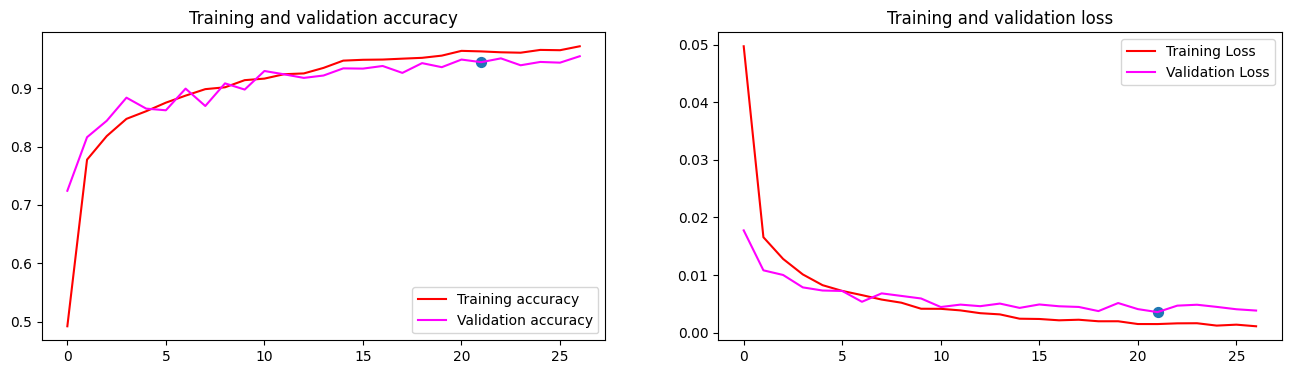

In [42]:
# Plot training results
import os
plot_loss_acc(history1.history)

In [43]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

In [44]:
predictions=model.predict(test_generator)

165/165 ━━━━━━━━━━━━━━━━━━━━ 68s 369ms/step


In [45]:
import numpy as np
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)
# Get true labels from the test generator
true_labels = test_generator.classes
# Compute the confusion matrix
conf_matrix = confusion_matrix(true_labels, predicted_classes)

# Print the confusion matrix
print("Confusion Matrix:")
print(conf_matrix)

Confusion Matrix:
[[ 327    1    2    0    1    2    0    1    3]
 [   5  310    1    0    0    0    0    1    2]
 [  49   47 2454   32    9   32   34   60   15]
 [   0    0    0  300    0    9    0    0    0]
 [   1    0    4    1  297    4    0    0    0]
 [   0    0    1    2    0  315    0    0    1]
 [   1    0    3    0    0    0  299    0    0]
 [   0    0    0    0    0    0    1  321    0]
 [  28    6    6    0    0    1    0    2  262]]


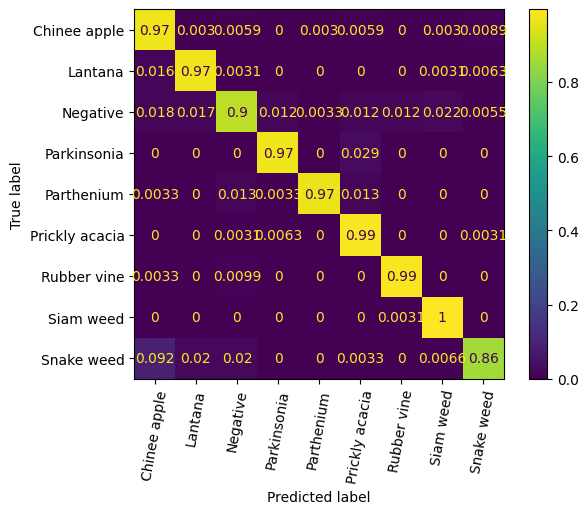

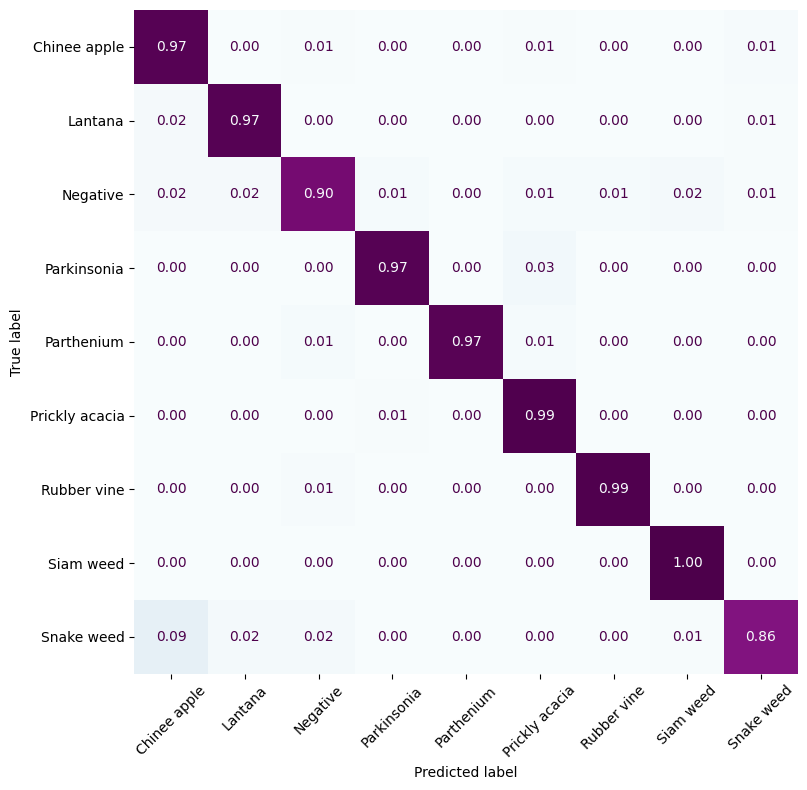

In [46]:
cmd = ConfusionMatrixDisplay.from_predictions(
        true_labels, predicted_classes,
        display_labels=list(test_generator.class_indices.keys()),
        xticks_rotation=80, #'vertical',
        normalize='true'
        # ax = ax
    )
    # fig, ax = plt.subplots(figsize=(25,5))
    # cmd.plot(ax=ax)
fig, ax = plt.subplots(figsize=(10, 8))
           # Remove axis spines (frame)
for spine in ax.spines.values():
        spine.set_visible(False)
cmd.plot(ax=ax, cmap='BuPu', xticks_rotation=45,  values_format='.2f', colorbar=False)
plt.tight_layout()
plt.savefig(os.path.join(save_folder, 'confusion-mat.png'))
plt.show()

In [47]:
display_labels=list(test_generator.class_indices.keys())
class_report=classification_report(true_labels, predicted_classes,digits=5, target_names=display_labels)
print(class_report)
# with open(os.path.join(save_folder, 'classification_report.txt'), 'w') as f:
#     f.write(classification_report(true_labels, predicted_classes))

                precision    recall  f1-score   support

  Chinee apple    0.79562   0.97033   0.87433       337
       Lantana    0.85165   0.97179   0.90776       319
      Negative    0.99312   0.89824   0.94330      2732
   Parkinsonia    0.89552   0.97087   0.93168       309
    Parthenium    0.96743   0.96743   0.96743       307
Prickly acacia    0.86777   0.98746   0.92375       319
   Rubber vine    0.89521   0.98680   0.93878       303
     Siam weed    0.83377   0.99689   0.90806       322
    Snake weed    0.92580   0.85902   0.89116       305

      accuracy                        0.92994      5253
     macro avg    0.89176   0.95654   0.92069      5253
  weighted avg    0.93768   0.92994   0.93081      5253



In [48]:
# # Unfreeze the base model
# base_model.trainable = True
# # It's important to recompile your model after you make any changes
# model.compile(loss='categorical_crossentropy',
#           optimizer= AdamW(learning_rate=1e-5,  weight_decay=5e-2),
#           metrics=['accuracy'])

In [49]:
# %%time
# # Train the model
# EPOCHS=15
# history2 = model.fit(
#       train_generator,
#       epochs=EPOCHS,
#       validation_data=validation_generator,
#       callbacks=[early_stopping, reduce_lr],
#     )

In [50]:
# # Plot training results
# plot_loss_acc(history2.history)

In [51]:
# predictions=model.predict(test_generator)

In [52]:
# import numpy as np
# from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
# import seaborn as sns
# import matplotlib.pyplot as plt
# # Convert predictions to class labels
# predicted_classes = np.argmax(predictions, axis=1)
# # Get true labels from the test generator
# true_labels = test_generator.classes
# # Compute the confusion matrix
# conf_matrix = confusion_matrix(true_labels, predicted_classes)

# # Print the confusion matrix
# print("Confusion Matrix:")
# print(conf_matrix)

In [53]:
# display_labels=list(test_generator.class_indices.keys())
# class_report=classification_report(true_labels, predicted_classes,digits=5, target_names=display_labels)
# print(class_report)
# with open(os.path.join(save_folder, 'classification_report.txt'), 'w') as f:
#     f.write(classification_report(true_labels, predicted_classes))